### Libraries

In [30]:
import os
import numpy as np
import nibabel as nb
from scipy.spatial.distance import pdist, squareform
from brainspace.plotting import plot_hemispheres
from brainspace.mesh.mesh_io import read_surface
from brainspace.datasets import load_mask

### Variables

In [31]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPEsurf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

mask_lh =  nb.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nb.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)

# Load fsLR 5k
f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

# Load fsLR 32k
f32k_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.surf.gii', itype='gii')
f32k_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.surf.gii', itype='gii')
# Load fsLR 32k inflated
f32k_inf_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.inflated.surf.gii', itype='gii')
f32k_inf_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.inflated.surf.gii', itype='gii')
mask_32k = load_mask(join=True)

# Boolean mask
#mask_surf = mask_5k != 0
mask_surf = mask_32k != 0

In [4]:
def compute_neighbors_from_geodesic(geo_dist, k=50):
    """
    geo_dist: (N, N) geodesic distance matrix
    k: number of neighbors
    """
    neighbors = []
    for v in range(geo_dist.shape[0]):
        # 자기 자신을 포함한 가장 가까운 k개의 vertex 선택
        neigh = np.argsort(geo_dist[v])[:k]
        neighbors.append(neigh)
    return np.array(neighbors)

## Load Geodesic distance connectome

In [7]:
# Set the path to the the geodesic distance connectome
cnt_gd = f'/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNC019/ses-03/dist/sub-PNC019_ses-03_surf-fsLR-5k_GD.shape.gii'

# Load the cortical connectome
mtx_gd = nb.load(cnt_gd).darrays[0].data

print(mtx_gd.shape)

(9684, 9684)


In [8]:
neighbors = compute_neighbors_from_geodesic(mtx_gd, k=50)
print(neighbors.shape)

(9684, 50)


In [9]:
def compute_variogram_geodesic(values, geo_dist, num_bins=20):
    N = len(values)

    # 상삼각만 사용 (대칭이므로)
    dist_vec = geo_dist[np.triu_indices(N, k=1)]
    diff_vec = (values[:, None] - values[None, :])[np.triu_indices(N, k=1)]**2

    bins = np.linspace(0, dist_vec.max(), num_bins + 1)
    gamma = []

    for b in range(num_bins):
        mask = (dist_vec >= bins[b]) & (dist_vec < bins[b+1])
        if np.sum(mask) > 0:
            gamma.append(np.mean(diff_vec[mask]) / 2)
        else:
            gamma.append(np.nan)

    return bins[:-1], np.array(gamma)

In [48]:
LFmap = np.load('/host/verges/tank/data/youngeun/myjupyter/array/AFD_par_average_SWM1mm_fsLR5k.npy') 
UFmap = np.load('/host/verges/tank/data/youngeun/myjupyter/array/AFD_perpav_average_SWM1mm_fsLR5k.npy') 
FA_LF = np.load('/host/verges/tank/data/youngeun/myjupyter/array/FA_par_average_SWM1mm_fsLR5k.npy') 
FA_UF = np.load('/host/verges/tank/data/youngeun/myjupyter/array/FA_perpav_average_SWM1mm_fsLR5k.npy') 
MD_LF = np.load('/host/verges/tank/data/youngeun/myjupyter/array/MD_par_average_SWM1mm_fsLR5k.npy') 
MD_UF = np.load('/host/verges/tank/data/youngeun/myjupyter/array/MD_perpav_average_SWM1mm_fsLR5k.npy') 
COMP_LF = np.load('/host/verges/tank/data/youngeun/myjupyter/array/COMP_par_average_SWM1mm_fsLR5k.npy') 
COMP_UF = np.load('/host/verges/tank/data/youngeun/myjupyter/array/COMP_perpav_average_SWM1mm_fsLR5k.npy') 

In [49]:
dist_bins, gammas = compute_variogram_geodesic(LFmap, mtx_gd)

In [13]:
def compute_local_heterogeneity(map_values, geo_dist, radius=10.0):
    """
    map_values : (N,) array — SWM depth profile or fiber-type ratio
    geo_dist   : (N, N) array — geodesic distances between all vertices
    radius     : float — neighborhood size (mm)
    """
    N = len(map_values)
    heterogeneity = np.zeros(N)

    for i in range(N):
        # 이 vertex 기준으로 radius 안의 이웃 찾기
        neigh_idx = np.where(geo_dist[i] < radius)[0]

        # 자기 자신만 있으면 이웃 없음 → heterogeneity = 0
        if len(neigh_idx) <= 1:
            heterogeneity[i] = 0
            continue

        # 이웃들의 값
        neigh_vals = map_values[neigh_idx]

        # 지역내 variability (표준편차)
        heterogeneity[i] = np.std(neigh_vals)

    return heterogeneity

In [58]:
hetero_u = compute_local_heterogeneity(
    map_values=LFmap,
    geo_dist=mtx_gd,
    radius=8.0  # mm 단위, 필요에 따라 5~15mm 조절
)

In [55]:
hetero_u[mask_5k==False] = np.nan

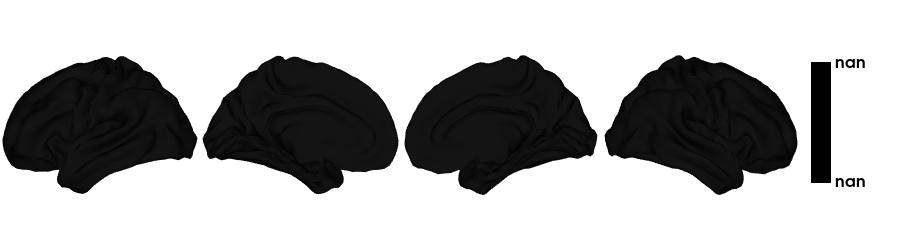

In [59]:
# Plot average SWM surfaces
plot_hemispheres(f5k_lh, f5k_rh, array_name=hetero_u, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='viridis', transparent_bg=False, screenshot=False)